In [ ]:
import zarr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd

import os
import sys

sys.path.append(os.path.abspath(".."))

from src import orderparameter as op

plt.style.use('../../my_style.mplstyle')

In [17]:
S_mean = []
S_std = []

for A in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    folder = f'/Volumes/data/Sasaki/backup_git/MTCargoSim/data/MT/P0.5_A{A:.1f}'
    S = op.ensembleS(folder)
    S_mean.append(np.mean(S, axis=0))
    S_std.append(np.std(S, axis=0))

'fig.savefig(f"{cd}/figure/neamtic_order_parameter_zoom.png", bbox_inches=\'tight\')\nfig.savefig(f"{cd}/figure/nematic_order_parameter_zoom.pdf", bbox_inches=\'tight\')'

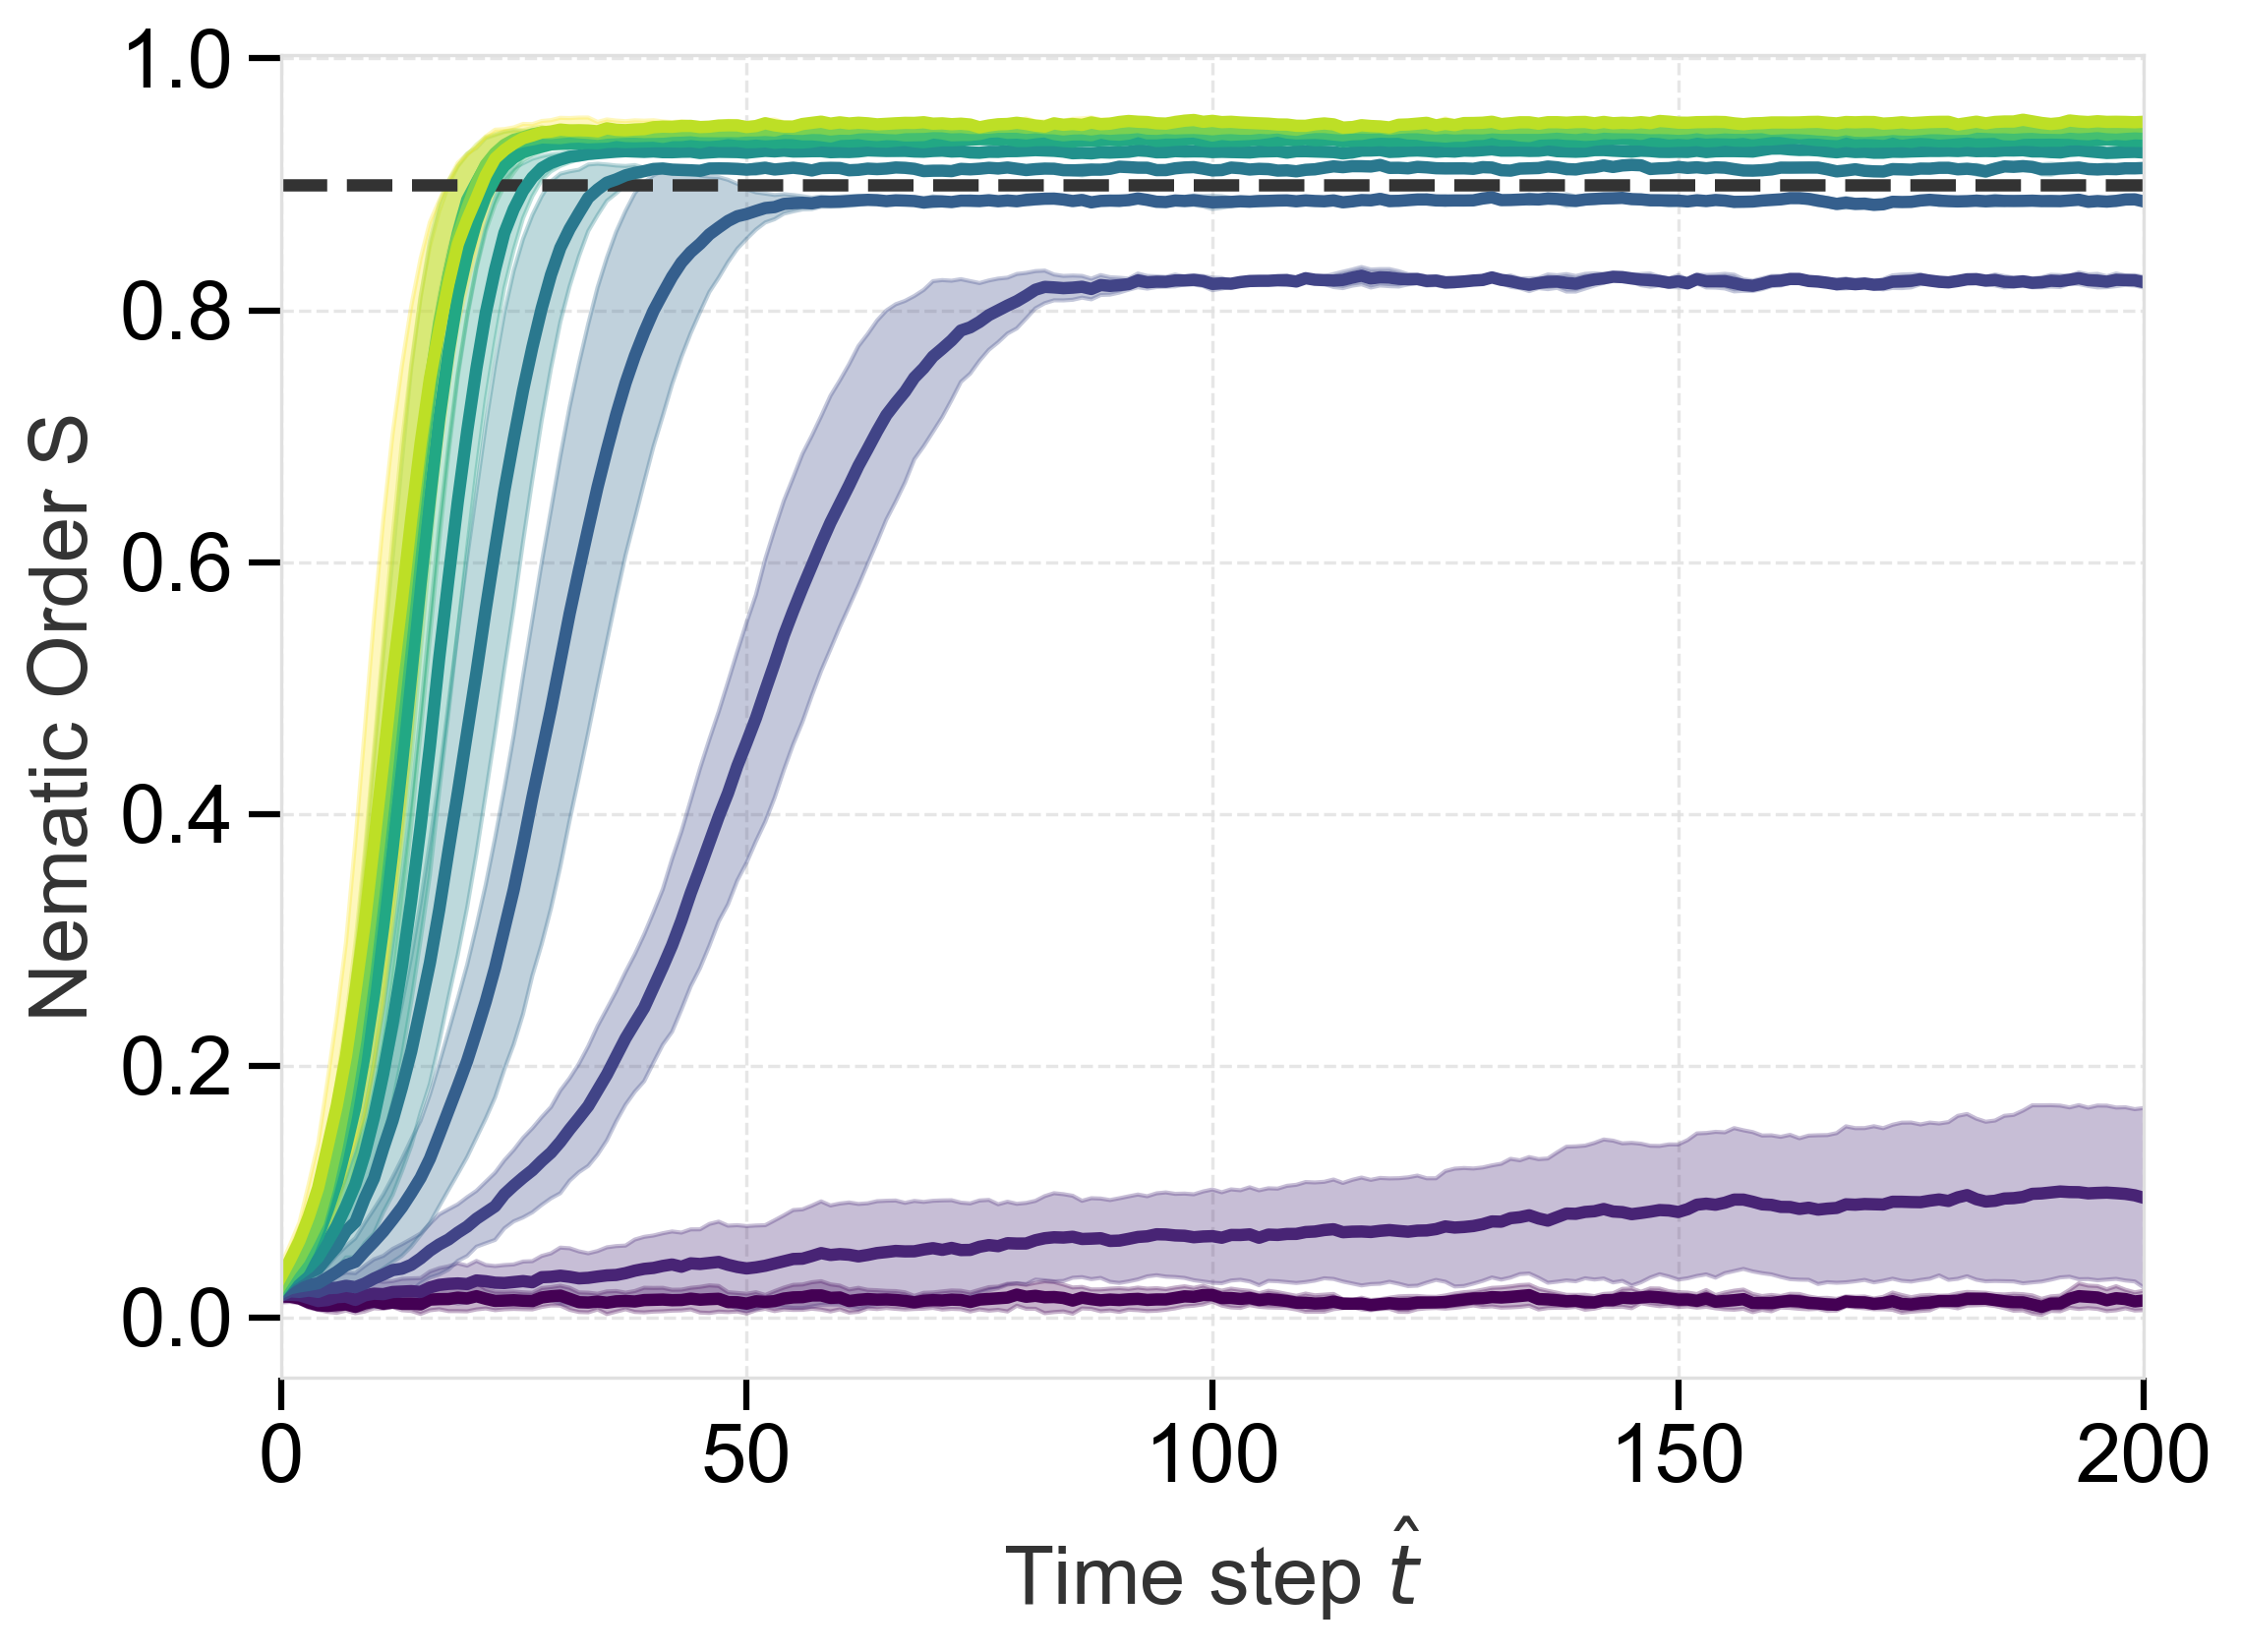

In [ ]:
fig, ax = plt.subplots()

for i in range(len(S_mean)):
    ax.plot(np.arange(len(S_mean[i])), S_mean[i], label=f'A={i*0.1:.1f}', color=plt.cm.viridis(i/10))
    ax.fill_between(np.arange(len(S_mean[i])), S_mean[i] - S_std[i], S_mean[i] + S_std[i], alpha=0.3, color=plt.cm.viridis(i/9))


ax.set(xlabel='Time step $\hat{t}$', ylabel='Nematic Order S', xlim = (0, 200))

cd=os.getcwd()

"""fig.savefig(f"{cd}/figure/neamtic_order_parameter_zoom.png", bbox_inches='tight')
fig.savefig(f"{cd}/figure/nematic_order_parameter_zoom.pdf", bbox_inches='tight')"""

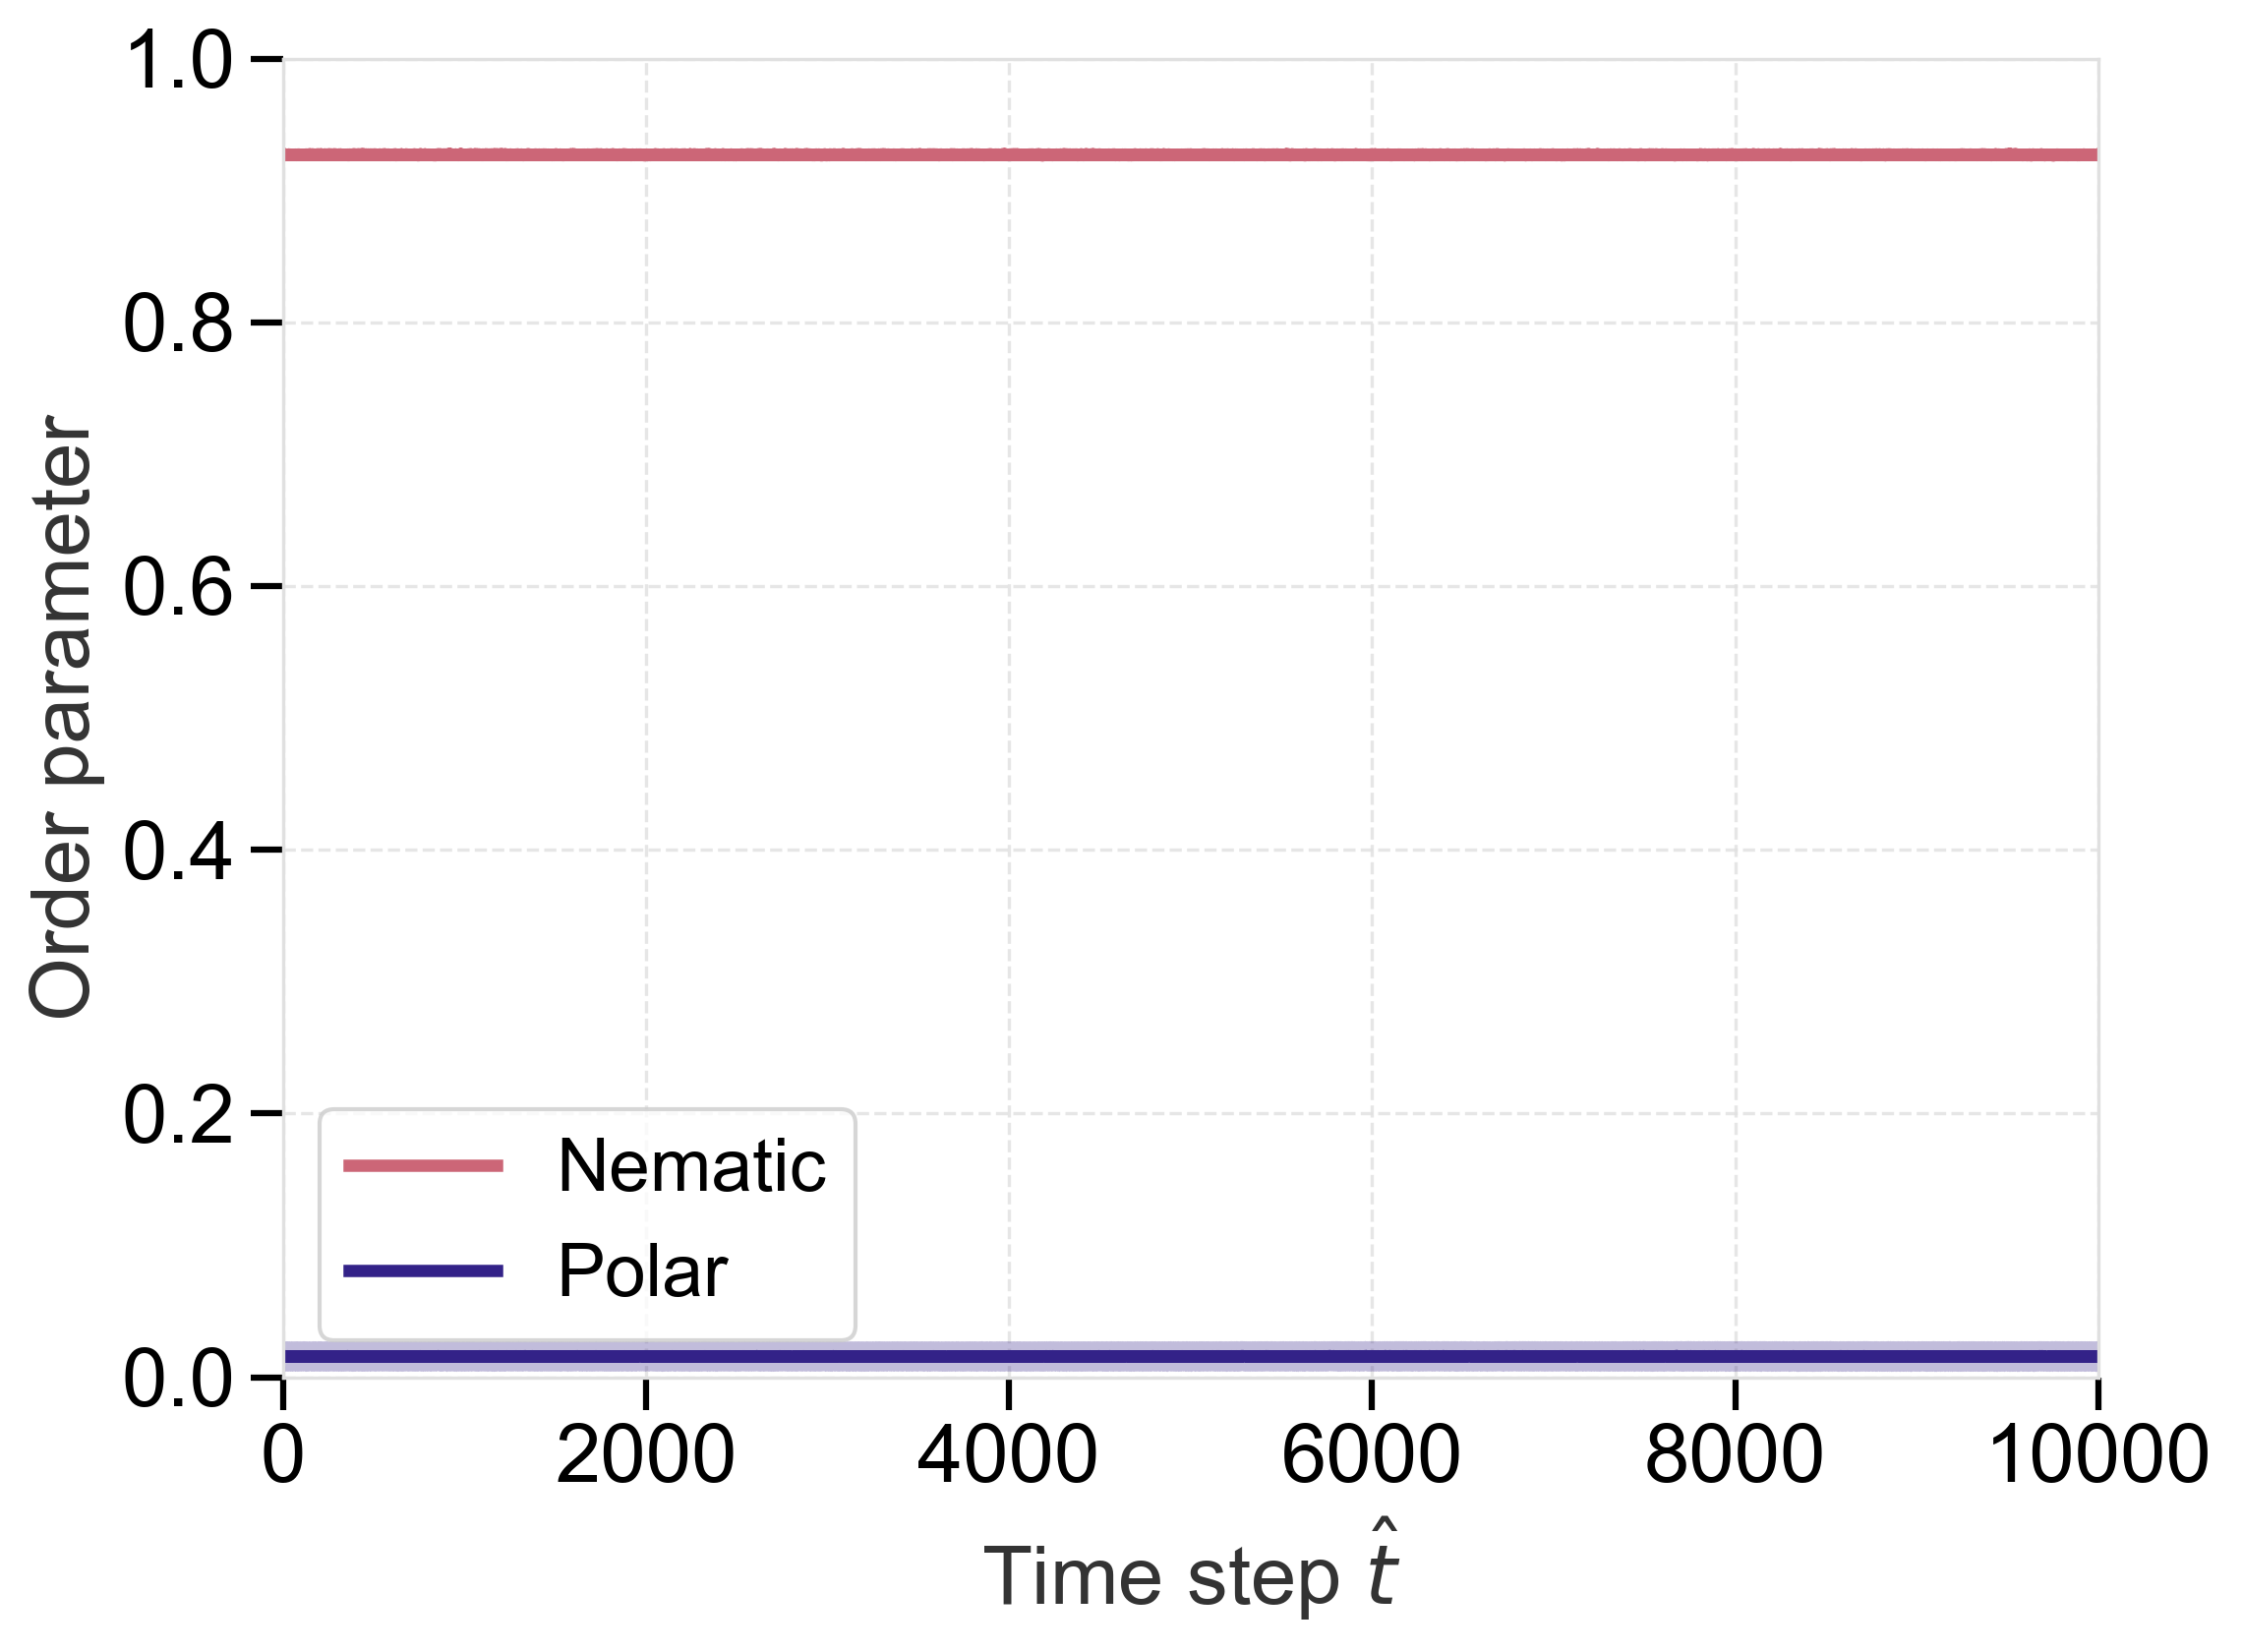

In [2]:
folder = "/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5"
S = op.ensembleS(folder)
P = op.ensembleP(folder)

fig, ax = plt.subplots()

ax.plot(np.arange(S.shape[1]), np.mean(S, axis=0), label = 'Nematic')
ax.fill_between(np.arange(S.shape[1]), np.mean(S, axis=0) - np.std(S, axis=0), np.mean(S, axis=0) + np.std(S, axis=0), alpha=0.3)

ax.plot(np.arange(P.shape[1]), np.mean(P, axis=0), label='Polar')
ax.fill_between(np.arange(P.shape[1]), np.mean(P, axis=0) - np.std(P, axis=0), np.mean(P, axis=0) + np.std(P, axis=0), alpha=0.3)

ax.set(xlabel='Time step $\hat{t}$', ylabel='Order parameter', xlim = (0, 1e4), ylim = (0, 1))
ax.legend()

cd=os.getcwd()

fig.savefig(f"{cd}/figure/order_parameter.png", bbox_inches='tight')
fig.savefig(f"{cd}/figure/order_parameter.pdf", bbox_inches='tight')

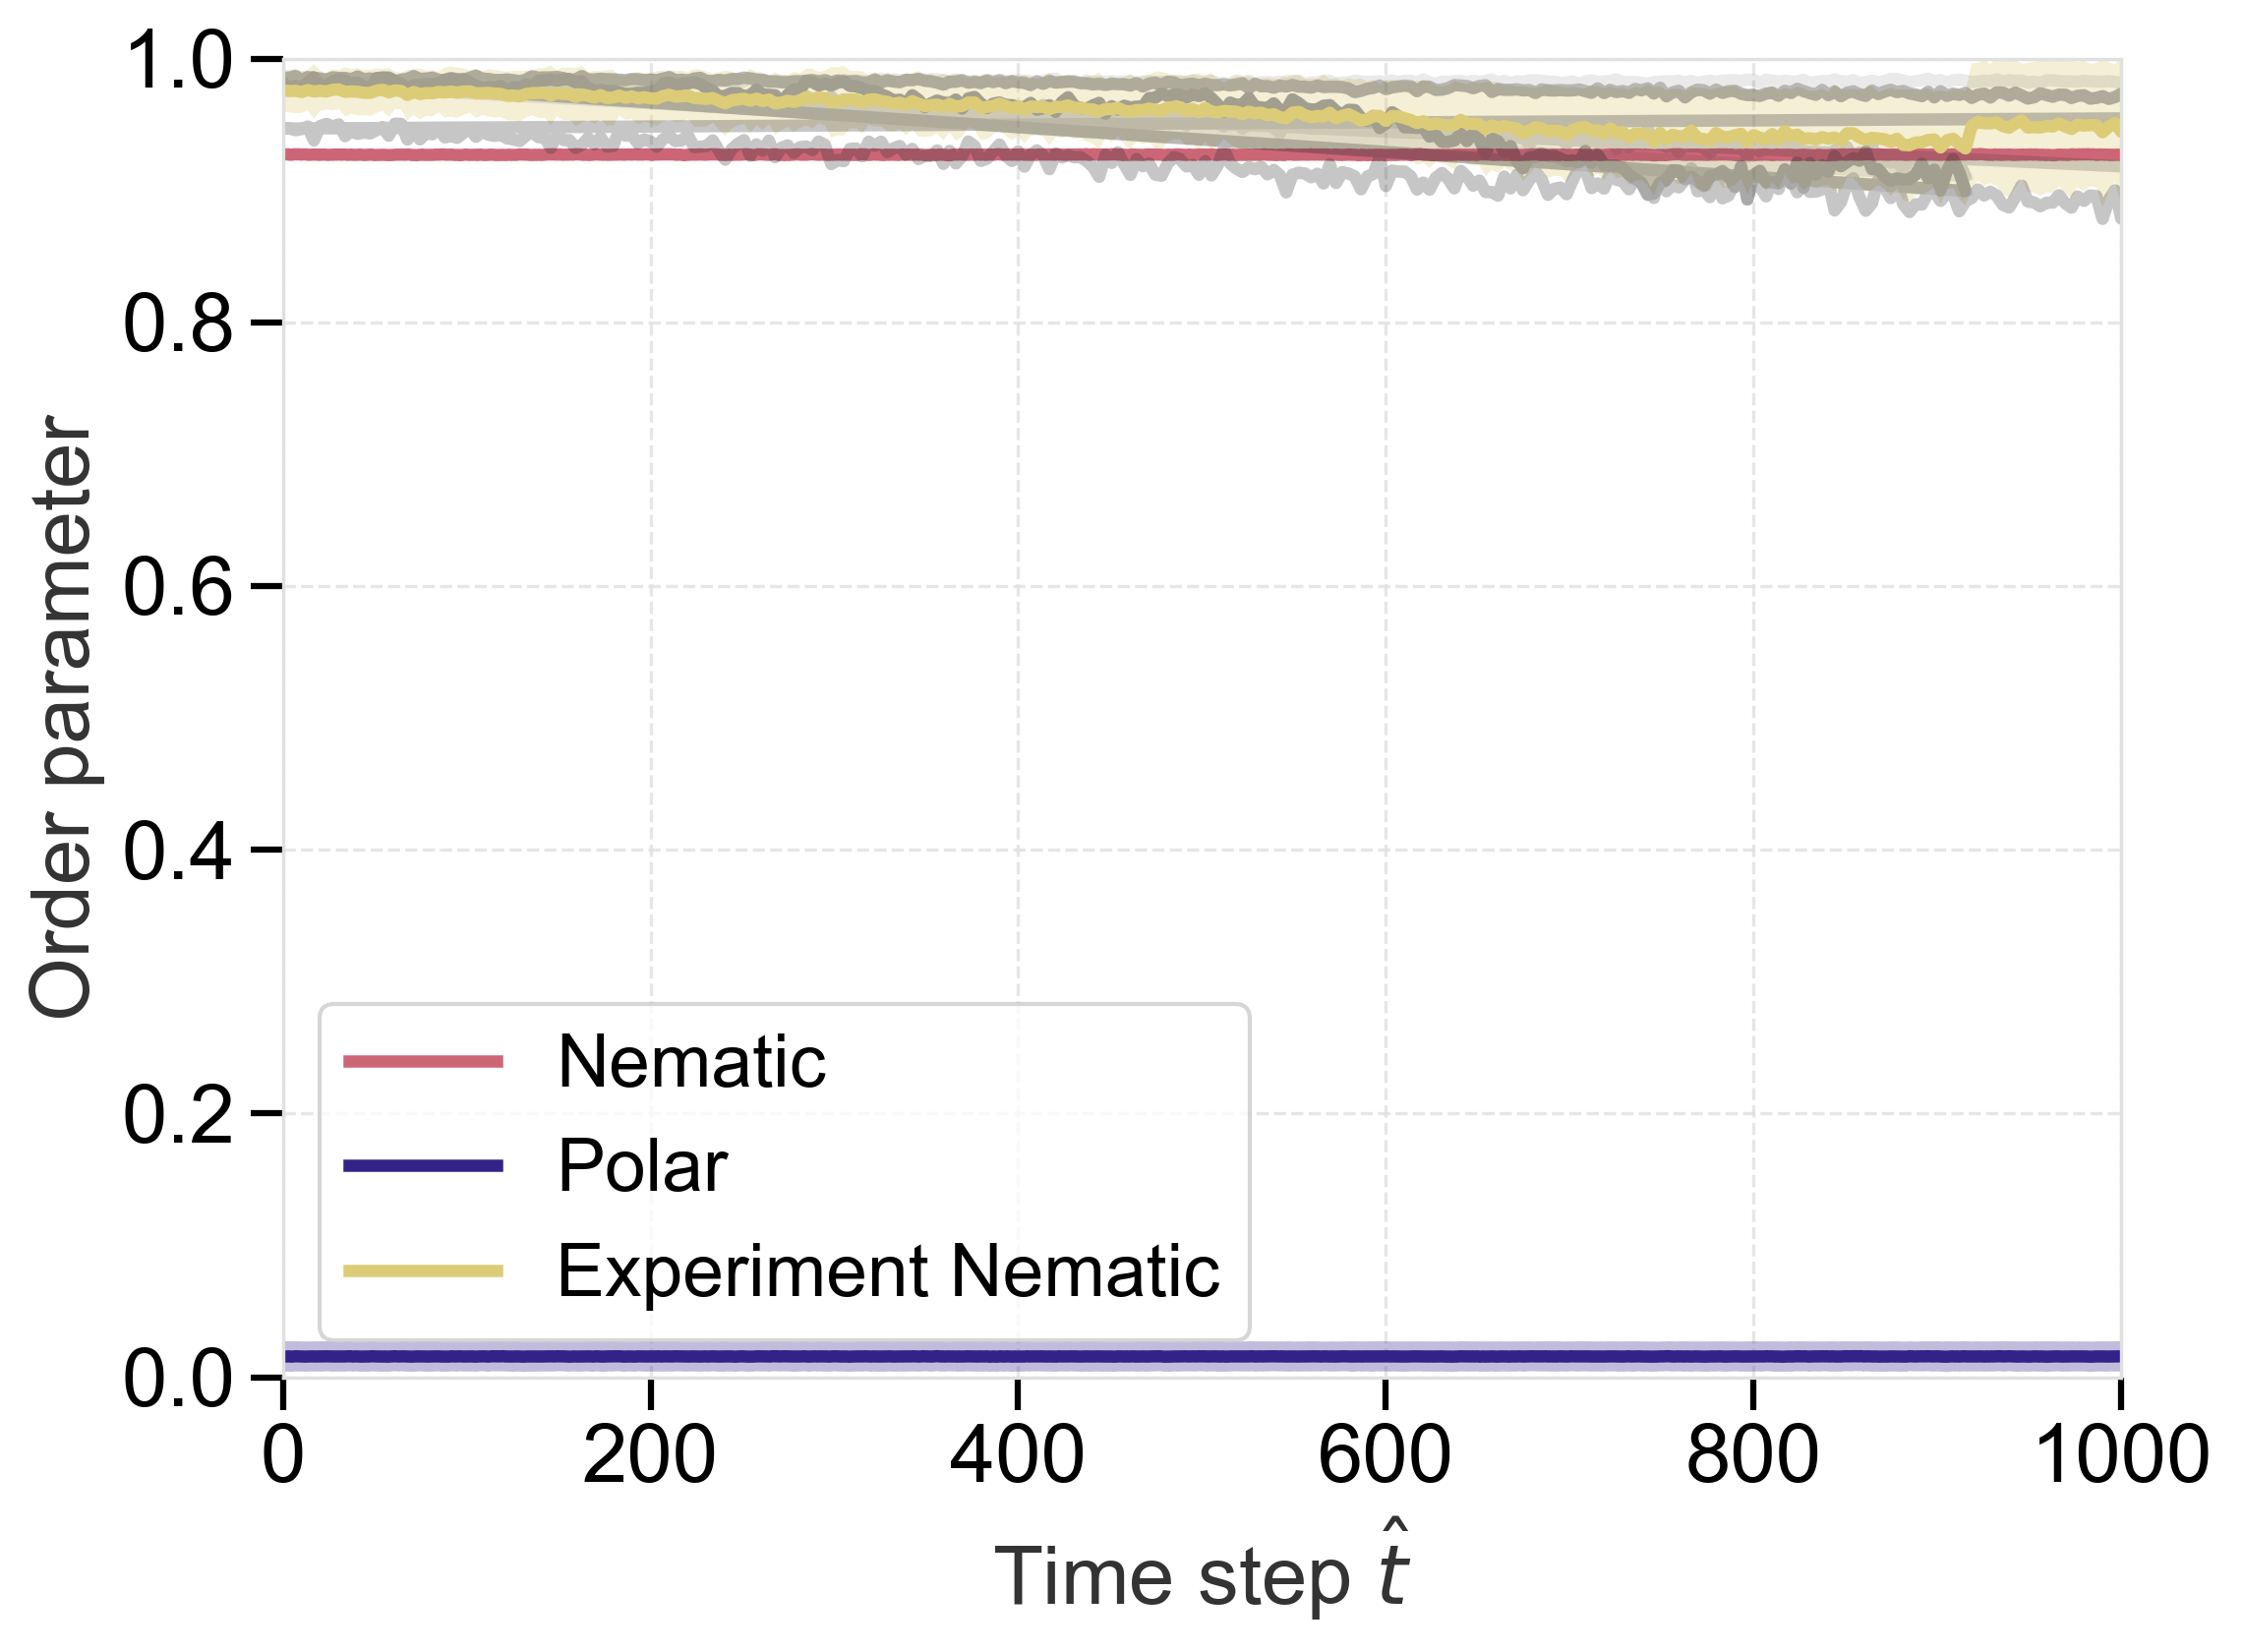

In [25]:
path0 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp"
path1 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001"
path2 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002"
path3 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop'
path4 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1'


tau = 1.18
fig, ax = plt.subplots()

ax.plot(np.arange(S.shape[1]), np.mean(S, axis=0), label = 'Nematic')
ax.fill_between(np.arange(S.shape[1]), np.mean(S, axis=0) - np.std(S, axis=0), np.mean(S, axis=0) + np.std(S, axis=0), alpha=0.3)

ax.plot(np.arange(P.shape[1]), np.mean(P, axis=0), label='Polar')
ax.fill_between(np.arange(P.shape[1]), np.mean(P, axis=0) - np.std(P, axis=0), np.mean(P, axis=0) + np.std(P, axis=0), alpha=0.3)

OP_t = []
OP_exp = []

for path in [path0, path1, path2, path3, path4]:
    order_path = os.path.join(path, 'order_parameter.zarr')
    order_zarr = zarr.open(order_path, mode='r')
    OP_t.extend(order_zarr[0,:]/tau)
    OP_exp.extend(order_zarr[1,:])
    ax.plot(OP_t, OP_exp, linestyle='-', color = "#333333", alpha = 0.1)

OP_df = pd.DataFrame({'t': OP_t, 'S': OP_exp}) 
exp_t = OP_df.groupby('t').mean().index
exp_S = OP_df.groupby('t').mean()['S']
exp_S_std = OP_df.groupby('t').std()['S']
ax.plot(exp_t, exp_S, label='Experiment Nematic')
ax.fill_between(exp_t, exp_S - exp_S_std, exp_S + exp_S_std, alpha=0.3)

ax.set(xlabel='Time step $\hat{t}$', ylabel='Order parameter', xlim = (0, 1e3), ylim = (0, 1))
ax.legend()

cd=os.getcwd()

fig.savefig(f"{cd}/figure/order_parameter_exp.png", bbox_inches='tight')
fig.savefig(f"{cd}/figure/order_parameter_exp.pdf", bbox_inches='tight')

In [14]:
OP_list = np.array([order_zarr[0,:]/tau, order_zarr[1,:]]).T

In [17]:
import pandas as pd

df=pd.DataFrame(OP_list, columns=['t', 'S'])

In [18]:
df

,t,S
0,0.000000,0.981526
1,3.389831,0.982234
2,6.779661,0.981261
3,10.169492,0.980799
4,13.559322,0.980981
...,...,...
486,1647.457627,0.982784
487,1650.847458,0.982725
488,1654.237288,0.983149
489,1657.627119,0.983057
